# Mozambique Drought Outlook: 2026/27 Season

**Source:** PRISM Anticipatory Action probabilities/triggers dataset
(`pa-rosea-support/raw/prism/aa_probabilities_triggers_moz.csv`, Azure Blob, `projects` container, `dev` stage).

This notebook reads the PRISM drought trigger monitoring data for Mozambique and summarizes what the
early forecast signal says about how the upcoming 2026/27 rainy season is shaping up, compared to the
three prior seasons in the dataset (2023-24, 2024-25, 2025-26).

**Scope:** limited to SPI (Standardized Precipitation Index) triggers. DRYSPELL (consecutive dry-day)
triggers are excluded from this notebook.

**How PRISM triggers work (as reflected in this data):** for each district, drought index (SPI over a
given month window, or consecutive dry-spell length), and severity category (Mild/Moderate/Severe), the
dataset tracks two checkpoints per activation window:
- **Readiness** (`*_ready`): an earlier checkpoint that puts responders on alert.
- **Set/Activation** (`*_set`): a later checkpoint that would actually activate anticipatory action.

At each checkpoint, a forecast **probability** (`prob_ready` / `prob_set`) of the dry outcome is compared
against a pre-set **trigger threshold** (`trigger_ready` / `trigger_set`). When probability ≥ threshold,
that checkpoint is considered "hit," meaning the early-warning signal has fired for that district/index/severity.

In [172]:
import ocha_stratus as stratus
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="white")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

df = stratus.load_csv_from_blob(
    "pa-rosea-support/raw/prism/aa_probabilities_triggers_moz.csv",
    stage="dev",
    container_name="projects",
)

df = df[df["index"].str.startswith("SPI")].reset_index(drop=True)  # SPI only, drop DRYSPELL indices
df["ready_hit"] = df["prob_ready"] >= df["trigger_ready"]
df["set_hit"] = df["prob_set"] >= df["trigger_set"]

rank = {"Mild": 1, "Moderate": 2, "Severe": 3}
df["cat_rank"] = df["category"].map(rank)

# Tomato-family severity palette used across all charts in this notebook
severity_colors = {"Severe": "#B22222", "Moderate": "#FF6347", "Mild": "#FFA07A", "Not triggered": "#c7c7c7"}

print(f"Shape: {df.shape}")
df.head()

Shape: (1232, 17)


,district,index,category,window,issue_ready,issue_set,trigger_ready,trigger_set,vulnerability,prob_ready,prob_set,season,date_ready,date_set,ready_hit,set_hit,cat_rank
0,Caia,SPI DJF,Mild,Window 1,8.0,9.0,0.27,0.00,Emergency Triggers,0.20,0.23,2023-24,2023-08-01,2023-09-01,False,True,1
1,Caia,SPI DJF,Moderate,Window 1,8.0,9.0,0.22,0.00,Emergency Triggers,0.17,0.18,2023-24,2023-08-01,2023-09-01,False,True,2
2,Caia,SPI MA,Moderate,Window 2,10.0,11.0,0.00,0.25,Emergency Triggers,0.11,0.16,2023-24,2023-10-01,2023-11-01,True,False,2
3,Caia,SPI MA,Moderate,Window 2,11.0,12.0,0.25,0.00,Emergency Triggers,0.16,0.49,2023-24,2023-11-01,2023-12-01,False,True,2
4,Caia,SPI MA,Severe,Window 2,10.0,11.0,0.00,0.24,Emergency Triggers,0.09,0.12,2023-24,2023-10-01,2023-11-01,True,False,3


## Dataset overview

- `district`: one of 36 monitored districts in Mozambique
- `index`: drought index, `SPI <months>` (Standardized Precipitation Index over a rolling window,
  e.g. `SPI OND` = Oct-Nov-Dec). DRYSPELL (consecutive dry-day) indices are excluded from this notebook.
- `category`: severity tier: Mild / Moderate / Severe
- `window`: activation Window 1 (earlier in the season) or Window 2 (later)
- `vulnerability`: which trigger tier applies: "Emergency Triggers" (higher-severity, larger response)
  or "General Triggers" (more easily reached, smaller/earlier response)
- `season`: the AA season the row belongs to (e.g. `2026-27`)

In [173]:
print("Seasons in data:", sorted(df["season"].unique()))
print("Districts monitored:", df["district"].nunique())
print("Index types:", sorted(df["index"].unique()))
print()
print("Rows per season:")
print(df["season"].value_counts().sort_index())

Seasons in data: ['2023-24', '2024-25', '2025-26', '2026-27']
Districts monitored: 40
Index types: ['SPI AM', 'SPI AMJ', 'SPI DJ', 'SPI DJF', 'SPI FM', 'SPI FMA', 'SPI JF', 'SPI JFM', 'SPI MA', 'SPI MAM', 'SPI MJ', 'SPI ND', 'SPI NDJ', 'SPI ON', 'SPI OND']

Rows per season:
season
2023-24    104
2024-25    341
2025-26    361
2026-27    426
Name: count, dtype: int64


## Where does the 2026/27 season stand right now?

Today is **10 July 2026**. The 2026/27 season has only just started reporting: so far only
**Window 1** forecasts have been issued (for the Oct-Nov-Dec planting-season indices), with readiness
checkpoints dated June/July 2026 and the first set/activation checkpoints dated July 2026. Later
checkpoints (Aug 2026 onward) are still `NaN`, since they haven't been forecast yet.

In [174]:
cur = df[df["season"] == "2026-27"].copy()

n_ready_pop = cur["prob_ready"].notna().sum()
n_set_pop = cur["prob_set"].notna().sum()
n_ready_hit = (cur["ready_hit"] & cur["prob_ready"].notna()).sum()
n_set_hit = (cur["set_hit"] & cur["prob_set"].notna()).sum()
districts_ready_hit = cur.loc[cur["ready_hit"] & cur["prob_ready"].notna(), "district"].nunique()
districts_total = cur["district"].nunique()

print(f"Readiness checkpoints issued so far: {n_ready_pop} of {len(cur)} rows")
print(f"  -> of those, {n_ready_hit} already meet/exceed their trigger threshold")
print(f"  -> spanning {districts_ready_hit} of {districts_total} monitored districts")
print()
print(f"Set/activation checkpoints issued so far: {n_set_pop} of {len(cur)} rows")
print(f"  -> of those, {n_set_hit} already meet/exceed their trigger threshold")

Readiness checkpoints issued so far: 105 of 426 rows
  -> of those, 100 already meet/exceed their trigger threshold
  -> spanning 38 of 39 monitored districts

Set/activation checkpoints issued so far: 28 of 426 rows
  -> of those, 28 already meet/exceed their trigger threshold


In [175]:
hotspots = (
    cur[cur["ready_hit"] & cur["prob_ready"].notna()]
    .assign(margin=lambda d: d["prob_ready"] - d["trigger_ready"])
    .sort_values("margin", ascending=False)
    [["district", "index", "category", "window", "vulnerability",
      "trigger_ready", "prob_ready", "margin", "date_ready"]]
)
print(f"{len(hotspots)} readiness triggers hit so far (2026-27), sorted by largest margin above threshold:")
hotspots.head(20)

100 readiness triggers hit so far (2026-27), sorted by largest margin above threshold:


,district,index,category,window,vulnerability,trigger_ready,prob_ready,margin,date_ready
859,Chibabava,SPI NDJ,Mild,Window 1,General Triggers,0.00,0.72,0.72,2026-07-01
1043,Machanga,SPI NDJ,Moderate,Window 1,General Triggers,0.04,0.70,0.66,2026-07-01
1042,Machanga,SPI NDJ,Mild,Window 1,General Triggers,0.16,0.77,0.61,2026-07-01
1041,Machanga,SPI ND,Severe,Window 1,General Triggers,0.07,0.56,0.49,2026-07-01
868,Chibuto,SPI NDJ,Mild,Window 1,General Triggers,0.31,0.71,0.40,2026-07-01
1174,Monapo,SPI NDJ,Moderate,Window 1,General Triggers,0.10,0.47,0.37,2026-07-01
935,Cidade Da Beira,SPI NDJ,Mild,Window 1,General Triggers,0.24,0.59,0.35,2026-07-01
969,Govuro,SPI NDJ,Severe,Window 1,General Triggers,0.34,0.69,0.35,2026-07-01
902,Chiure,SPI ND,Mild,Window 1,General Triggers,0.19,0.53,0.34,2026-07-01
1208,Namuno,SPI NDJ,Moderate,Window 1,General Triggers,0.10,0.41,0.31,2026-07-01


## Current season (2026-27) status by SPI window

A count of districts per category, one row per SPI window per lead time, for the 2026-27 season only.
Each window is monitored on a rolling monthly cadence (e.g. SPI ND is checked in Jun, Jul, and Aug),
so the tables are split by the calendar month the checkpoint was issued (`issue_ready` / `issue_set`),
not just by window, to show how the picture sharpens as later, closer-to-season checkpoints come in.

Two tables below: one for the **readiness** checkpoint (`prob_ready` vs `trigger_ready`) and one for
the later **set/activation** checkpoint (`prob_set` vs `trigger_set`). A district only counts toward
a category if its probability actually cleared that category's threshold, not merely because a
forecast exists for it. The set table will be much sparser right now, since set checkpoints for most
windows have not been issued yet this season.

Restricted to windows whose accumulation period ends on or before January 2027 (`SPI ON`, `SPI OND`,
`SPI ND`, `SPI NDJ`, `SPI DJ`), since those are the only windows with any issued forecasts so far.
Later windows (e.g. `SPI DJF`, `SPI JF`, and beyond) are excluded here as they extend past January 2027
and have not been forecast yet.

In [176]:
current_windows = ["SPI ON", "SPI OND", "SPI ND", "SPI NDJ", "SPI DJ"]


def build_window_status_table(windows, prob_col, trigger_col, hit_col, issue_col, season="2026-27"):
    month_names = {6: "Jun", 7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}

    subset = df[(df["season"] == season) & (df["index"].isin(windows))]
    avail = subset[subset[prob_col].notna()]
    hit = avail[avail[hit_col]]

    worst = hit.groupby(["index", issue_col, "district"])["cat_rank"].max().reset_index()
    worst["worst_category"] = worst["cat_rank"].map({v: k for k, v in rank.items()})

    monitored = avail.groupby(["index", issue_col])["district"].nunique()
    triggered = worst.groupby(["index", issue_col]).size()

    row_order = [
        (w, m) for w in windows
        for m in sorted(avail.loc[avail["index"] == w, issue_col].dropna().unique())
    ]
    row_index = pd.MultiIndex.from_tuples(row_order, names=["index", issue_col])

    table = (
        worst.groupby(["index", issue_col, "worst_category"]).size()
        .unstack(fill_value=0)
        .reindex(index=row_index, columns=["Severe", "Moderate", "Mild"], fill_value=0)
    )
    table["Not triggered"] = (
        monitored.reindex(row_index, fill_value=0) - triggered.reindex(row_index, fill_value=0)
    ).clip(lower=0)
    table["Districts available"] = monitored.reindex(row_index, fill_value=0)

    table.index = pd.MultiIndex.from_tuples(
        [(w, month_names.get(int(m), str(int(m)))) for w, m in table.index],
        names=["SPI window", "Lead time (issued)"]
    )
    return table


def lighten(hex_color, factor=0.8):
    hex_color = hex_color.lstrip("#")
    r, g, b = (int(hex_color[i:i + 2], 16) for i in (0, 2, 4))
    r, g, b = (int(v + (255 - v) * factor) for v in (r, g, b))
    return f"#{r:02x}{g:02x}{b:02x}"


def style_window_table(table, caption):
    column_tints = {
        "Severe": lighten(severity_colors["Severe"]),
        "Moderate": lighten(severity_colors["Moderate"]),
        "Mild": lighten(severity_colors["Mild"]),
        "Not triggered": lighten(severity_colors["Not triggered"]),
        "Districts available": lighten("#E9967A"),
    }

    styled = (
        table.style
        .set_caption(caption)
        .format("{:.0f}")
        .set_table_styles([
            {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "bold"),
                                               ("font-size", "12px"), ("padding-bottom", "4px"),
                                               ("text-align", "left")]},
            {"selector": "th", "props": [("text-align", "center"), ("background-color", "#f2f2f2"),
                                          ("padding", "2px 8px"), ("font-size", "12px"),
                                          ("line-height", "1.1")]},
            {"selector": "td", "props": [("text-align", "center"), ("padding", "2px 8px"),
                                          ("font-size", "12px"), ("line-height", "1.1")]},
        ])
    )
    for col, color in column_tints.items():
        styled = styled.set_properties(subset=[col], **{"background-color": color})
    return styled


readiness_window_table = build_window_status_table(current_windows, "prob_ready", "trigger_ready", "ready_hit", "issue_ready")
style_window_table(readiness_window_table, "Upcoming season (2026-27) status by SPI window: readiness")

In [177]:
set_window_table = build_window_status_table(current_windows, "prob_set", "trigger_set", "set_hit", "issue_set")
style_window_table(set_window_table, "Upcoming season (2026-27) status by SPI window: set")

,worst_category,Severe,Moderate,Mild,Not triggered,Districts available
SPI window,Lead time (issued),,,,,
SPI OND,Jul,2,3,3,0,8
SPI ND,Jul,7,2,3,0,12


## How does this compare to previous seasons?

The dataset covers four seasons. To gauge whether 2026/27 is trending worse or better than recent years,
we compare how many readiness/set checkpoints were hit **relative to how many had been issued**,
since 2026/27 is still early and only partially reported.

**Caveat:** the `vulnerability` (Emergency vs General trigger tier) labels look unfinalized for
2026-27: 380 of 382 rows are labeled "General Triggers" vs. a much more even mix in prior seasons
(see table below). This looks like a data-pipeline artifact rather than a genuine downgrade in
district vulnerability, so tier-level (Emergency vs General) comparisons should be treated with caution
for the current season until confirmed with the PRISM data owners.

In [178]:
season_summary = []
for season, g in df.groupby("season"):
    ready_pop = g["prob_ready"].notna().sum()
    set_pop = g["prob_set"].notna().sum()
    ready_hit = (g["ready_hit"] & g["prob_ready"].notna()).sum()
    set_hit = (g["set_hit"] & g["prob_set"].notna()).sum()
    season_summary.append({
        "season": season,
        "readiness_issued": ready_pop,
        "readiness_hit": ready_hit,
        "districts_w_readiness_hit": g.loc[g["ready_hit"] & g["prob_ready"].notna(), "district"].nunique(),
        "set_issued": set_pop,
        "set_hit": set_hit,
    })
season_summary = pd.DataFrame(season_summary).set_index("season")
season_summary

,readiness_issued,readiness_hit,districts_w_readiness_hit,set_issued,set_hit
season,,,,,
2023-24,104,59,12,104,72
2024-25,341,186,20,339,165
2025-26,361,148,32,361,78
2026-27,105,100,38,28,28


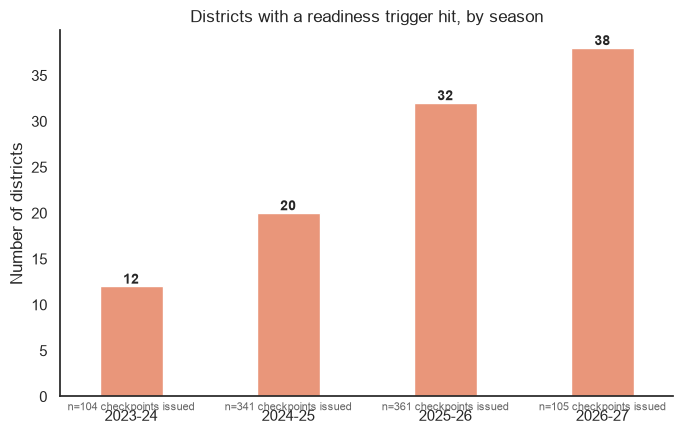

In [179]:
fig, ax = plt.subplots(figsize=(7, 4.5))
season_summary["districts_w_readiness_hit"].plot(kind="bar", ax=ax, color="#E9967A", width=0.4)
ax.set_ylabel("Number of districts")
ax.set_xlabel(None)
ax.set_title("Districts with a readiness trigger hit, by season")
ax.yaxis.set_major_locator(mticker.MultipleLocator(5))

for i, (season, row) in enumerate(season_summary.iterrows()):
    ax.text(i, row["districts_w_readiness_hit"] + 0.3, str(int(row["districts_w_readiness_hit"])),
            ha="center", fontsize=10, fontweight="bold")
    ax.text(i, -1.5, f"n={int(row['readiness_issued'])} checkpoints issued",
            ha="center", fontsize=8, color="#666666")

plt.xticks(rotation=0)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [180]:
vuln_by_season = df.groupby(["season", "vulnerability"]).size().unstack(fill_value=0)
vuln_by_season

vulnerability,Emergency Triggers,General Triggers
season,,
2023-24,63,41
2024-25,341,0
2025-26,78,283
2026-27,2,424


## Severity breakdown: Mild / Moderate / Severe, by season

The hit-rate view above tells us *how many* checkpoints fired, but not *how severe*. Here we look at
each district's **worst readiness-hit category** per season (Severe > Moderate > Mild), and how many
districts fall into each bucket.

**Important caveat:** the number of districts monitored has grown a lot over the life of the program:
12 in 2023-24, 20 in 2024-25, 33 in 2025-26. For 2026-27, "monitored" below counts only districts
that have at least one issued (non-blank) readiness forecast so far, so it will grow over the season
as more checkpoints are issued rather than jumping straight to the full district roster. Raw district
counts aren't directly comparable across seasons for that reason alone, so the chart below labels each
season's bar with how many districts were monitored that year, alongside the raw counts per category.

In [181]:
hit_rows = df[df["ready_hit"] & df["prob_ready"].notna()]
worst = hit_rows.groupby(["season", "district"])["cat_rank"].max().reset_index()
worst["worst_category"] = worst["cat_rank"].map({v: k for k, v in rank.items()})

monitored = df[df["prob_ready"].notna()].groupby("season")["district"].nunique()  # only districts with an issued forecast
triggered = worst.groupby("season").size()

severity_counts = (
    worst.groupby(["season", "worst_category"]).size()
    .unstack(fill_value=0)
    .reindex(columns=["Severe", "Moderate", "Mild"], fill_value=0)
)
severity_counts["Not triggered"] = (monitored - triggered).clip(lower=0)
severity_counts["Districts monitored"] = monitored
severity_counts

worst_category,Severe,Moderate,Mild,Not triggered,Districts monitored
season,,,,,
2023-24,12,0,0,0,12
2024-25,20,0,0,0,20
2025-26,26,6,0,1,33
2026-27,28,3,7,0,38


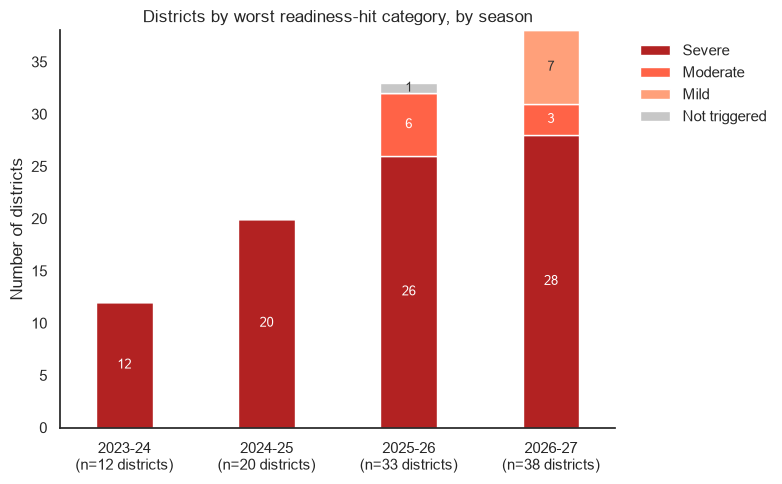

In [182]:
plot_cols = ["Severe", "Moderate", "Mild", "Not triggered"]

fig, ax = plt.subplots(figsize=(8, 5))
severity_counts[plot_cols].plot(kind="bar", stacked=True, ax=ax, color=[severity_colors[c_] for c_ in plot_cols], width=0.4)

ax.set_title("Districts by worst readiness-hit category, by season")
ax.set_xlabel(None)
ax.set_ylabel("Number of districts")
ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
xticklabels = [f"{s}\n(n={n} districts)" for s, n in severity_counts["Districts monitored"].astype(int).items()]
ax.set_xticklabels(xticklabels, rotation=0)
ax.legend(title=None, loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)

for i, season in enumerate(severity_counts.index):
    cum = 0
    for col in plot_cols:
        count = severity_counts.loc[season, col]
        if count > 0:
            text_color = "white" if col in ("Severe", "Moderate") else "#333333"
            ax.text(i, cum + count / 2, str(int(count)), ha="center", va="center",
                    fontsize=9, color=text_color)
        cum += count

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**Reading this chart:** the earlier hit-rate chart shows 2026/27 flagging more districts, earlier, than
prior seasons. This chart adds severity. On severity composition among triggered districts, 2026/27 is
actually *less* Severe-skewed than 2023-24 and 2024-25, where effectively every triggered district's
worst hit was already Severe, and is roughly in line with 2025-26. So the honest read is that this
season is flagging **more districts, earlier**, using only Window 1 data so far, but not necessarily
with a *more severe* mix than recent seasons once a district is flagged at all. That could still shift
once Window 2 (core season) forecasts land, since severity typically hardens as the season progresses
and more indices report in.

## Severity breakdown by SPI accumulation window (SPI-2 vs SPI-3)

The severity view above pools every SPI window together. Here we split out two commonly used window
lengths separately, all seasons shown:

- **SPI-2** (`SPI ON`, `SPI ND`, `SPI DJ`): 2-month accumulations, sensitive to shorter dry spells
  within the Oct-Nov / Nov-Dec / Dec-Jan windows. Districts are pooled across all three so a district
  counts once toward its single worst category, not once per window.
- **SPI-3** (`SPI NDJ`, `SPI OND`): 3-month accumulations (Nov-Dec-Jan or Oct-Nov-Dec), smoothing over
  short dry spells to capture more sustained seasonal dryness. Districts are pooled across both so a
  district counts once toward its single worst category, not once per window.

As before, each district is scored by its worst readiness-hit category (Severe over Moderate over Mild)
within the given window, per season. Not every district has both windows tracked in every season, so
"districts monitored" differs from the full district total and from the all-SPI figures above.

In [183]:
def worst_category_table(subset, prob_col="prob_ready", hit_col="ready_hit"):
    hit = subset[subset[hit_col] & subset[prob_col].notna()]
    worst = hit.groupby(["season", "district"])["cat_rank"].max().reset_index()
    worst["worst_category"] = worst["cat_rank"].map({v: k for k, v in rank.items()})

    monitored = subset[subset[prob_col].notna()].groupby("season")["district"].nunique()  # only districts with an issued forecast
    triggered = worst.groupby("season").size()

    table = (
        worst.groupby(["season", "worst_category"]).size()
        .unstack(fill_value=0)
        .reindex(index=monitored.index, columns=["Severe", "Moderate", "Mild"], fill_value=0)
    )
    table["Not triggered"] = (monitored - triggered).clip(lower=0)
    table["Districts monitored"] = monitored
    return table


def plot_severity_counts(table, title):
    plot_cols = ["Severe", "Moderate", "Mild", "Not triggered"]

    fig, ax = plt.subplots(figsize=(5, 3))
    table[plot_cols].plot(kind="bar", stacked=True, ax=ax, color=[severity_colors[c_] for c_ in plot_cols], width=0.4)
    ax.set_title(title)
    ax.set_xlabel(None)
    ax.set_ylabel("Number of districts")
    ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
    xticklabels = [f"{s}\n(n={n} districts)" for s, n in table["Districts monitored"].astype(int).items()]
    ax.set_xticklabels(xticklabels, rotation=0)
    ax.legend(title=None, loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)

    for i, season in enumerate(table.index):
        cum = 0
        for col in plot_cols:
            count = table.loc[season, col]
            if count > 0:
                text_color = "white" if col in ("Severe", "Moderate") else "#333333"
                ax.text(i, cum + count / 2, str(int(count)), ha="center", va="center",
                        fontsize=9, color=text_color)
            cum += count

    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()


def plot_severity_counts_side_by_side(table_ready, table_set, suptitle):
    plot_cols = ["Severe", "Moderate", "Mild", "Not triggered"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, table, subtitle in zip(axes, [table_ready, table_set], ["Readiness", "Set"]):
        table[plot_cols].plot(kind="bar", stacked=True, ax=ax,
                               color=[severity_colors[c_] for c_ in plot_cols], legend=False, width=0.4)
        ax.set_title(subtitle)
        ax.set_xlabel(None)
        ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
        xticklabels = [f"{s}\n({n} districts)" for s, n in table["Districts monitored"].astype(int).items()]
        ax.set_xticklabels(xticklabels, rotation=0)

        for i, season in enumerate(table.index):
            cum = 0
            for col in plot_cols:
                count = table.loc[season, col]
                if count > 0:
                    text_color = "white" if col in ("Severe", "Moderate") else "#333333"
                    ax.text(i, cum + count / 2, str(int(count)), ha="center", va="center",
                            fontsize=9, color=text_color)
                cum += count
        sns.despine(ax=ax)

    axes[0].set_ylabel("Number of districts")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=4, frameon=False)
    fig.suptitle(suptitle, y=1.18, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_severity_counts_grid(tables, titles, suptitle, ncols=2):
    plot_cols = ["Severe", "Moderate", "Mild", "Not triggered"]
    nrows = -(-len(tables) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4.5 * nrows), sharey=True)
    axes = axes.flatten()

    for ax, table, subtitle in zip(axes, tables, titles):
        table[plot_cols].plot(kind="bar", stacked=True, ax=ax,
                               color=[severity_colors[c_] for c_ in plot_cols], legend=False, width=0.4)
        ax.set_title(subtitle)
        ax.set_xlabel(None)
        ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
        xticklabels = [f"{s}\n({n} districts)" for s, n in table["Districts monitored"].astype(int).items()]
        ax.set_xticklabels(xticklabels, rotation=0)

        for i, season in enumerate(table.index):
            cum = 0
            for col in plot_cols:
                count = table.loc[season, col]
                if count > 0:
                    text_color = "white" if col in ("Severe", "Moderate") else "#333333"
                    ax.text(i, cum + count / 2, str(int(count)), ha="center", va="center",
                            fontsize=9, color=text_color)
                cum += count
        sns.despine(ax=ax)

    for ax in axes[::ncols]:
        ax.set_ylabel("Number of districts")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=4, frameon=False)
    fig.suptitle(suptitle, y=1.12, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [184]:
severity_counts_spi2 = worst_category_table(df[df["index"].isin(["SPI ON", "SPI ND", "SPI DJ"])])
severity_counts_spi2_set = worst_category_table(
    df[df["index"].isin(["SPI ON", "SPI ND", "SPI DJ"])], prob_col="prob_set", hit_col="set_hit"
)
severity_counts_spi2

worst_category,Severe,Moderate,Mild,Not triggered,Districts monitored
season,,,,,
2023-24,3,3,1,2,9
2024-25,8,2,2,5,17
2025-26,11,3,7,12,33
2026-27,11,5,7,1,24


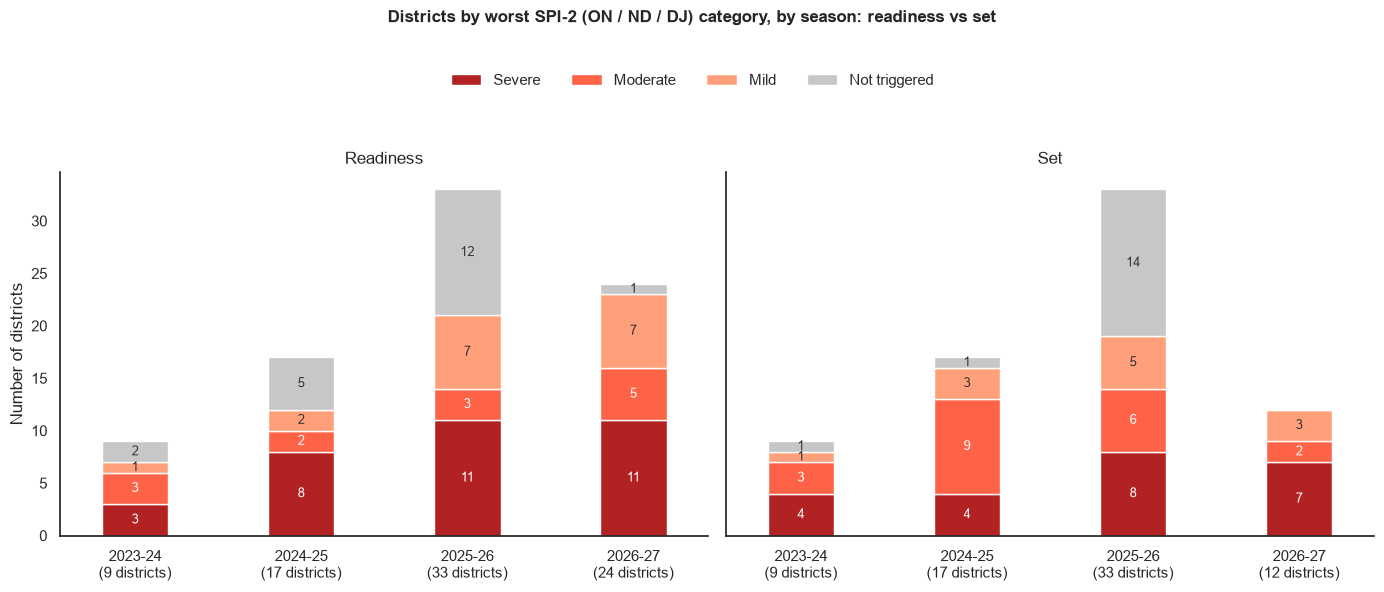

In [185]:
plot_severity_counts_side_by_side(
    severity_counts_spi2, severity_counts_spi2_set,
    "Districts by worst SPI-2 (ON / ND / DJ) category, by season: readiness vs set"
)

In [186]:
severity_counts_spi3 = worst_category_table(df[df["index"].isin(["SPI NDJ", "SPI OND"])])
severity_counts_spi3_set = worst_category_table(
    df[df["index"].isin(["SPI NDJ", "SPI OND"])], prob_col="prob_set", hit_col="set_hit"
)
severity_counts_spi3

worst_category,Severe,Moderate,Mild,Not triggered,Districts monitored
season,,,,,
2023-24,4,0,3,2,9
2024-25,9,5,3,2,19
2025-26,12,7,2,9,30
2026-27,22,4,6,0,32


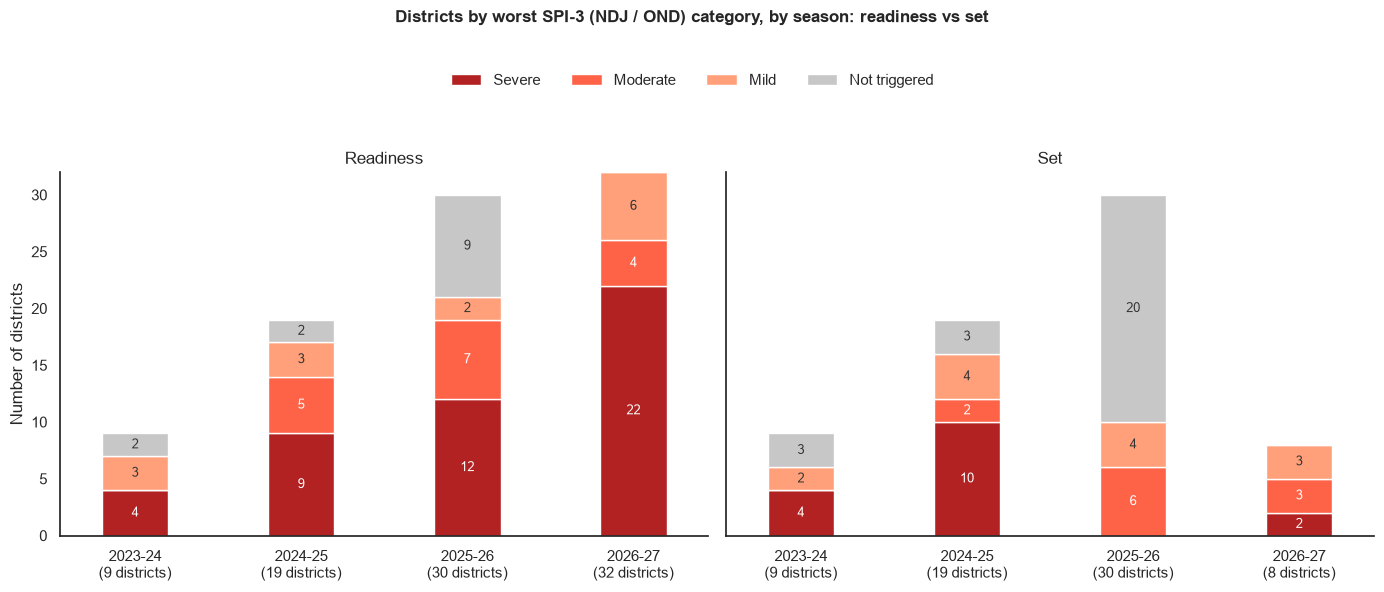

In [187]:
plot_severity_counts_side_by_side(
    severity_counts_spi3, severity_counts_spi3_set,
    "Districts by worst SPI-3 (NDJ / OND) category, by season: readiness vs set"
)

### Combined (SPI-2 + SPI-3)

Pools all five windows above (`SPI ON`, `SPI ND`, `SPI DJ`, `SPI NDJ`, `SPI OND`) into one severity
score per district, per season: a district counts once toward its single worst category across every
window it's tracked in, rather than being split out by window length.

In [188]:
combined_windows = ["SPI ON", "SPI ND", "SPI DJ", "SPI NDJ", "SPI OND"]

severity_counts_spi_all = worst_category_table(df[df["index"].isin(combined_windows)])
severity_counts_spi_all_set = worst_category_table(
    df[df["index"].isin(combined_windows)], prob_col="prob_set", hit_col="set_hit"
)
severity_counts_spi_all

worst_category,Severe,Moderate,Mild,Not triggered,Districts monitored
season,,,,,
2023-24,7,2,2,0,11
2024-25,14,3,2,1,20
2025-26,19,6,3,5,33
2026-27,28,3,7,0,38


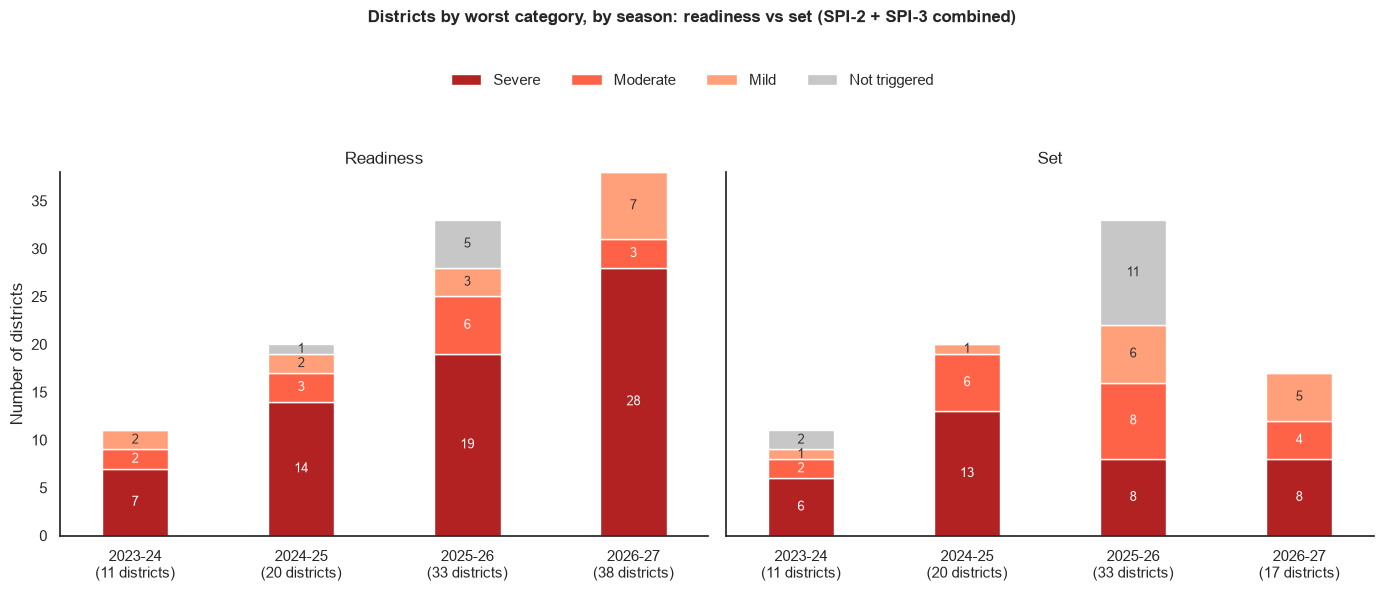

In [189]:
plot_severity_counts_side_by_side(
    severity_counts_spi_all, severity_counts_spi_all_set,
    "Districts by worst category, by season: readiness vs set (SPI-2 + SPI-3 combined)"
)

### SPI-3 (NDJ / OND) category breakdown, 2026/27 season only

The table below pulls just the 2026-27 row from the SPI-3 (NDJ / OND, pooled) breakdown above,
showing how many districts fall into each category for this season specifically.

In [190]:
spi3_2026 = (
    severity_counts_spi3.loc["2026-27", ["Severe", "Moderate", "Mild", "Not triggered"]]
    .rename("Districts")
    .to_frame()
)
spi3_2026.index.name = "Category"
spi3_2026

,Districts
Category,
Severe,22
Moderate,4
Mild,6
Not triggered,0


## Assessment: how bad is the 2026/27 season shaping up to be?

Based on the readiness-stage forecasts issued so far (Window 1 only, covering Oct-Nov-Dec planting-season
indices):

- **97% of issued readiness checkpoints (90 of 93) already meet or exceed their activation threshold**,
  spanning **34 of the 35 monitored districts** with data so far: almost every monitored district has
  at least one dryness index flashing above its early-warning threshold.
- That hit rate is **far higher than the equivalent early-season signal in prior years**: 57% in
  2023-24, 55% in 2024-25, and 41% in 2025-26. Even allowing for the fact that 2026-27 is only
  partially observed, this is a notably wide and early spread of above-threshold dryness signals.
- Looking at each district's *worst* hit category so far: 24 of 34 triggered districts (71%) are
  already at **Severe**, 3 at Moderate, 7 at Mild. That's a real severe-drought signal in most
  triggered districts, but it is *not* a higher Severe-share than 2023-24 or 2024-25 (100% of
  triggered districts were Severe in both those seasons) and is similar to 2025-26 (81%). So the
  standout feature of 2026-27 so far is **breadth** (more districts flagged, earlier), not an
  unusually severe mix once flagged. See the severity breakdown chart above.
- All of this is currently sitting in the **"General Triggers"** tier in the data; because that tier
  split looks unfinalized for 2026-27 (see caveat above), we can't yet say how many of these would
  translate into higher-severity **Emergency**-tier activations once tiers are properly assigned.

**Bottom line:** the earliest available forecast signal points to a season trending **drier/more
concerning than the last three seasons on record**, with unusually broad geographic spread this early
in the forecast cycle. This is a probabilistic early-warning signal, not a confirmed outcome. Window 2
forecasts (Dec-Jan-Feb core season) will start landing from **August 2026** and should be re-checked as
they arrive, since they cover the peak of the rainy season and will be more decisive.

## Caveats & recommended follow-ups

- **Only Window 1 (early-season) forecasts are in yet.** Window 2 (core Dec-Jan-Feb / Jan-Feb-Mar
  indices) starts landing from August 2026. Re-run this notebook monthly as new checkpoints post.
- **"Hit" = forecast probability ≥ activation threshold, not observed drought.** These are lead-time
  seasonal forecast probabilities (readiness/set checkpoints), not ground-truth rainfall outcomes.
- **Vulnerability/trigger-tier (Emergency vs General) labels for 2026-27 look unfinalized.** Confirm
  with the PRISM/AA data owners before drawing tier-specific conclusions.
- **Cross-check against independent rainfall products** (e.g. IMERG/CHIRPS, as used in the `flood/`
  analyses in this repo) and food-security monitoring (IPC) before using this for programming decisions.